In [1]:
import logging

import numpy as np

from pomaar.array_synthesizer import ArraySynthesizer, interleave_linear_arrays

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

### Texas Instruments, AWRx cascaded radar RF evaluation module (MMWCAS-RF-EVM)
**Array structure:** The system is a $12\times16$ layout of series-fed patch antennas, built upon a 4-chip cascaded architecture. The receive array is divided into 3 sub-arrays ($8+4+4$), each containing active elements with a parasitic element on each side (not shown here) to facilitate more uniform embedded pattern via periodic repetition. The transmit array is an undivided 12-element array with mild non-uniformity in elevation.

**MIMO topology:**
- The 3 receive ULAs in azimuth are separated by $\lambda/2$.
- The transmitter array consists of a 9-element ULA with $2\lambda$ spacing in azimuth with an embedded 4-element minimum redundancy array (MRA) in elevation.

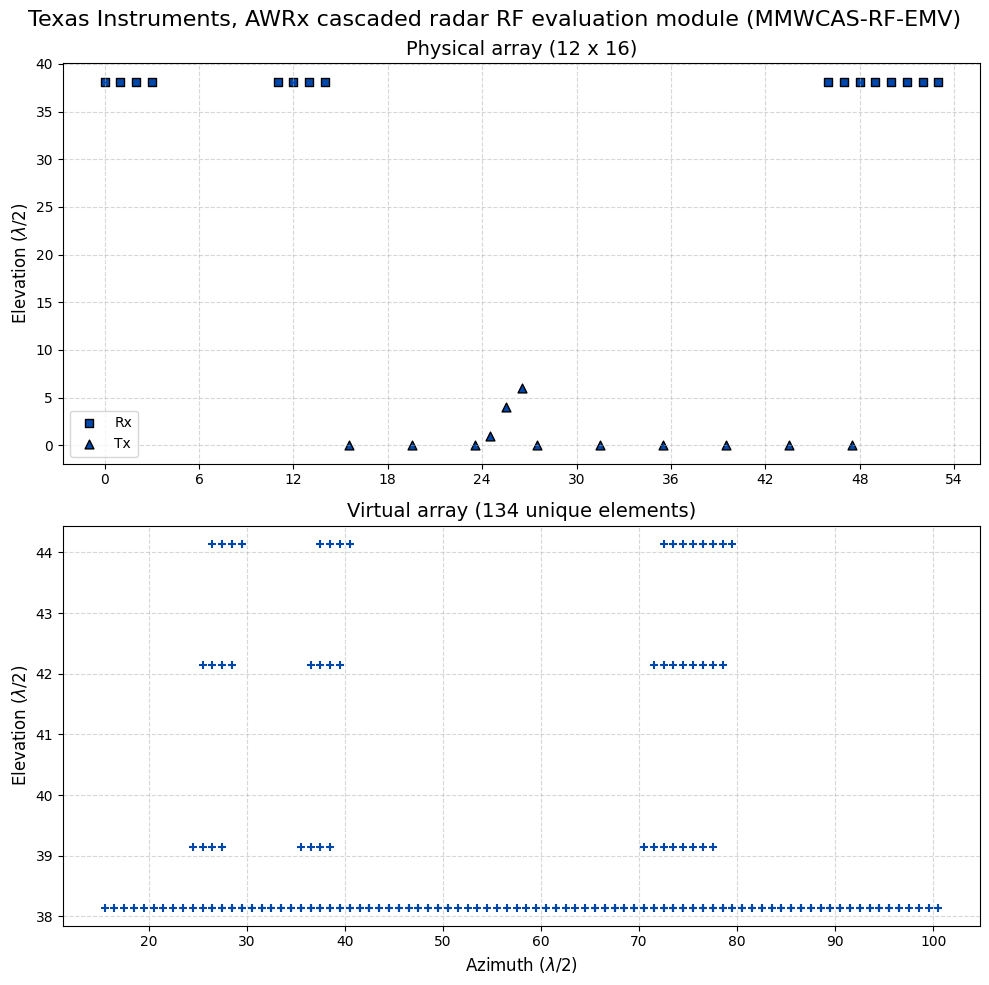

In [2]:
rx_ula = np.arange(0, 4, 1)
rx_b = np.column_stack((rx_ula, np.zeros_like(rx_ula)))
rx_c = rx_b[-1] + [8, 0] + rx_b
rx_ula = np.arange(0, 8, 1)
rx_a = rx_c[-1] + [32, 0] + np.column_stack((rx_ula, np.zeros_like(rx_ula)))
rx = [0, 2 * 19.072] + np.vstack((rx_a, rx_b, rx_c))

tx_ula = np.arange(0, 9 * 4, 4)
tx_azimuth = np.column_stack((tx_ula, np.zeros_like(tx_ula)))
tx_mra = tx_azimuth[2] + np.column_stack((np.arange(1, 4, 1), [1, 4, 6]))
tx = [2 * 7.759, 0] + np.vstack((tx_azimuth, tx_mra))

mimo = ArraySynthesizer(
    name="Texas Instruments, AWRx cascaded radar RF evaluation module (MMWCAS-RF-EMV)", highlight_overlaps=False
)
mimo.set_arrays(tx, rx)
mimo.plot_topology(marker_size=40)

### Tinti et al., Fully polarimetric automotive radar: proof of concept (2024)
**Array structure:** The system features a $12\times16$ MIMO array with H- and V-polarized sectoral horn antennas with rectangular milled step tapering. The array is constructed such that the 12 transmitters are divided into six H-polarized elements and six V-polarized elements. Likewise, the 16 receivers are divided into eight H-polarized and eight V-polarized elements. This uniform arrangement, with proper spacing, results in 192 virtual elements, divided into four subarrays of 48 elements, one for each of the four possible polarization combinations.

**MIMO topology:** To facilitate unambiguous angular estimation, the target virtual array is synthesized to be uniform with half-wavelength element spacing. Specifically, this is achieved using the following strategy:
- Rx and Tx arrays are vertically displaced (by a distance of about $4\lambda$) into two non-uniform linear arrays.
- The receiver array (positioned at the top) is split into two uniform linear arrays (ULAs) with element spacing of $\lambda$, separated by $13\lambda$.
- Transmitters (in the bottom row) are grouped in pairs, separated by $1.5\lambda$, with inter-pair distance of $8\lambda$.

INFO: 45 calibration overlaps found: (-22.0, 8.0), (-21.0, 8.0), (-20.0, 8.0), (-19.0, 8.0), (-18.0, 8.0), (-17.0, 8.0), (-16.0, 8.0), (-15.0, 8.0), (-14.0, 8.0), (-13.0, 8.0), (-12.0, 8.0), (-11.0, 8.0), (-10.0, 8.0), (-9.0, 8.0), (-8.0, 8.0), (-7.0, 8.0), (-6.0, 8.0), (-5.0, 8.0), (-4.0, 8.0), (-3.0, 8.0), (-2.0, 8.0), (-1.0, 8.0), (0.0, 8.0), (1.0, 8.0), (2.0, 8.0), (3.0, 8.0), (4.0, 8.0), (5.0, 8.0), (6.0, 8.0), (7.0, 8.0), (8.0, 8.0), (9.0, 8.0), (10.0, 8.0), (11.0, 8.0), (12.0, 8.0), (13.0, 8.0), (14.0, 8.0), (15.0, 8.0), (16.0, 8.0), (17.0, 8.0), (18.0, 8.0), (19.0, 8.0), (20.0, 8.0), (21.0, 8.0), (22.0, 8.0)


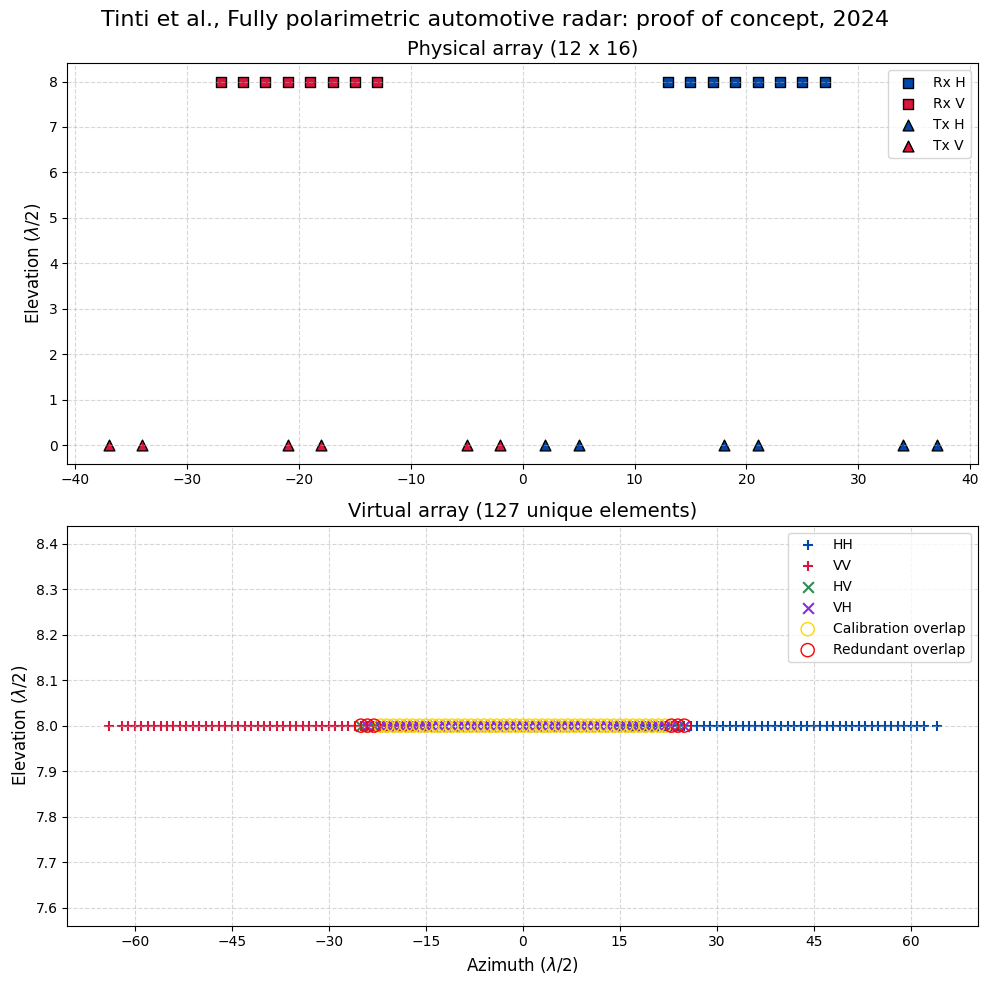

In [3]:
# Rx: Two eight-element ULAs, one for each polarization, with one-wavelength spacing
# Azimuth: sub-arrays displaced by 13 wavelengths apart
# Elevation: Rx array shifted up by about 4 wavelengths
spacing = 2
rx_ula = np.arange(0, 8 * spacing, spacing)
rx_ula = np.column_stack((rx_ula, np.zeros_like(rx_ula)))
rx_h = [13, 8] + rx_ula
rx_v = [-13, 8] - rx_ula

# Tx
tx_pair = np.array([[0, 0], [3, 0]])
offsets = np.array([[0, 0], [16, 0], [32, 0]])
tx_pairs = (offsets[:, None, :] + tx_pair[None, :, :]).reshape(-1, 2)
tx_h = [2, 0] + tx_pairs
tx_v = [-2, 0] - tx_pairs

mimo = ArraySynthesizer(
    name="Tinti et al., Fully polarimetric automotive radar: proof of concept, 2024", highlight_overlaps=True
)
mimo.set_arrays(tx_h=tx_h, rx_h=rx_h, tx_v=tx_v, rx_v=rx_v)
mimo.plot_topology(marker_size=60)

### Rectangular 12x16 array

A simple array idea.

**Observations:**
- Impossible to obtain useful overlaps while maintaining a rectangular shape **without interleaving elements**.
- Embedded pattern will likely be heavily influenced by coupling, especially in the corners of neighbouring transmitters and receivers. 

In [4]:
interleave = True
offset = 2
spacing = 2

tx_ula = np.arange(0, 6 * spacing, spacing)
rx_ula = np.arange(0, 8 * spacing, spacing)
tx_h = np.column_stack((offset + tx_ula, np.zeros_like(tx_ula)))
rx_h = np.column_stack((2 * offset + spacing * (len(tx_ula) - 1) * np.ones_like(rx_ula), offset + rx_ula))
tx_v = np.column_stack((offset + tx_ula, 2 * offset + spacing * (len(rx_ula) - 1) * np.ones_like(tx_ula)))
rx_v = np.column_stack((np.zeros_like(rx_ula), offset + rx_ula))

if interleave:
    tx_h, tx_v = interleave_linear_arrays(tx_h, tx_v)
    rx_h, rx_v = interleave_linear_arrays(rx_h, rx_v)

mimo = ArraySynthesizer(name="Zero-redundancy rectangular array")
mimo.set_arrays(tx_h=tx_h, rx_h=rx_h, tx_v=tx_v, rx_v=rx_v, centre=True)
# mimo.plot_topology()


### Square 12x16 array

The same simple array idea, now with filled corners.

In [5]:
interleave = True
spacing = 2
tx_ula = np.arange(0, 6 * spacing, spacing)
rx_ula = np.arange(0, 8 * spacing, spacing)

tx_h = np.column_stack((tx_ula, np.zeros_like(tx_ula)))
rx_h = np.column_stack((spacing * len(tx_ula) * np.ones_like(rx_ula), rx_ula))
tx_v = np.column_stack((tx_ula + spacing, spacing * len(rx_ula) * np.ones_like(tx_ula)))
rx_v = np.column_stack((np.zeros_like(rx_ula), rx_ula + spacing))

if interleave:
    tx_h, tx_v = interleave_linear_arrays(tx_h, tx_v)
    rx_h, rx_v = interleave_linear_arrays(rx_h, rx_v)

mimo = ArraySynthesizer(name="Zero-redundancy square array")
mimo.set_arrays(tx_h=tx_h, rx_h=rx_h, tx_v=tx_v, rx_v=rx_v, centre=True)
# mimo.plot_topology()


### Custom design \#1: Overlapped cross-polar channels in the middle
- **Sparse transmit array and uniform receive array:** The most straightforward way to achieve a dense ULA in the virtual array is to construct one (transmit or receive) array as a dense ULA with a spacing of $d_\mathrm{Rx}$ and the other as a sparse ULA with a spacing of $d_\mathrm{Tx}=N_{Rx}d_\mathrm{Rx}$.
    - Since we strive to achieve a $\lambda/2$-ULA, we set $d_\mathrm{Rx}=\lambda/2$ and obtain $d_\mathrm{Tx}=N_\mathrm{Rx}$.
    - The reason why we build a sparse transmit array and a dense receive array is that the receive array has more elements. Therefore, shifting one transmit element in elevation creates an array more populated in azimuth at that elevation level. Apparently, the receive elements also have tighter requirements on the strict phase-matching than elements in the transmit array.
- **Factorization of the receive array:** To minimize routing losses, we optimize the chip-to-antenna route to be as short as possible. This makes grouping many receive elements together impractical due to the need of equal feed lengths.
    - As in the Texas Instruments example, a synchronized chip cascade (e.g. with 3 outputs and 4 inputs per chip) is used to feed the large receive array factorized into multiple sub-arrays.
    - Spatial displacement of these receive sub-arrays must be optimized to achieve several goals, such as sufficient redundancy in azimuth to facilitate cross-chip amplitude and phase mismatches while maximizing angular resolution.
- **Reserve transmit elements for elevation**
- **Feasibility of DOA estimation across different channels:** The angle-estimation algorithms cannot account for the uncorrelated scattering mechanisms and phase returns, especially when the target scattering is depolarizing like in the case of automotive scenarios. Therefore, each polarimetric sub-array basically reconstructs its own image and cannot utilize other channels to improve this information. However, it is algebraically possible to take both cross-polarized channels as equal, since, as theory of reciprocal media states, the off-diagonal scattering parameters should be equal in amplitude and phase for monostatic scattering. Considering that any residual imbalance, stemming for instance from different dynamic and temperature ranges of LNAs across individual channels, we could form a larger linear array in azimuth out of the cross-polar channels combined and perform DOA on it to increase azimuth resolution.

INFO: 17 calibration overlaps found: (-8.0, 12.0), (-7.0, 12.0), (-6.0, 12.0), (-5.0, 12.0), (-4.0, 12.0), (-3.0, 12.0), (-2.0, 12.0), (-1.0, 12.0), (0.0, 12.0), (1.0, 12.0), (2.0, 12.0), (3.0, 12.0), (4.0, 12.0), (5.0, 12.0), (6.0, 12.0), (7.0, 12.0), (8.0, 12.0)


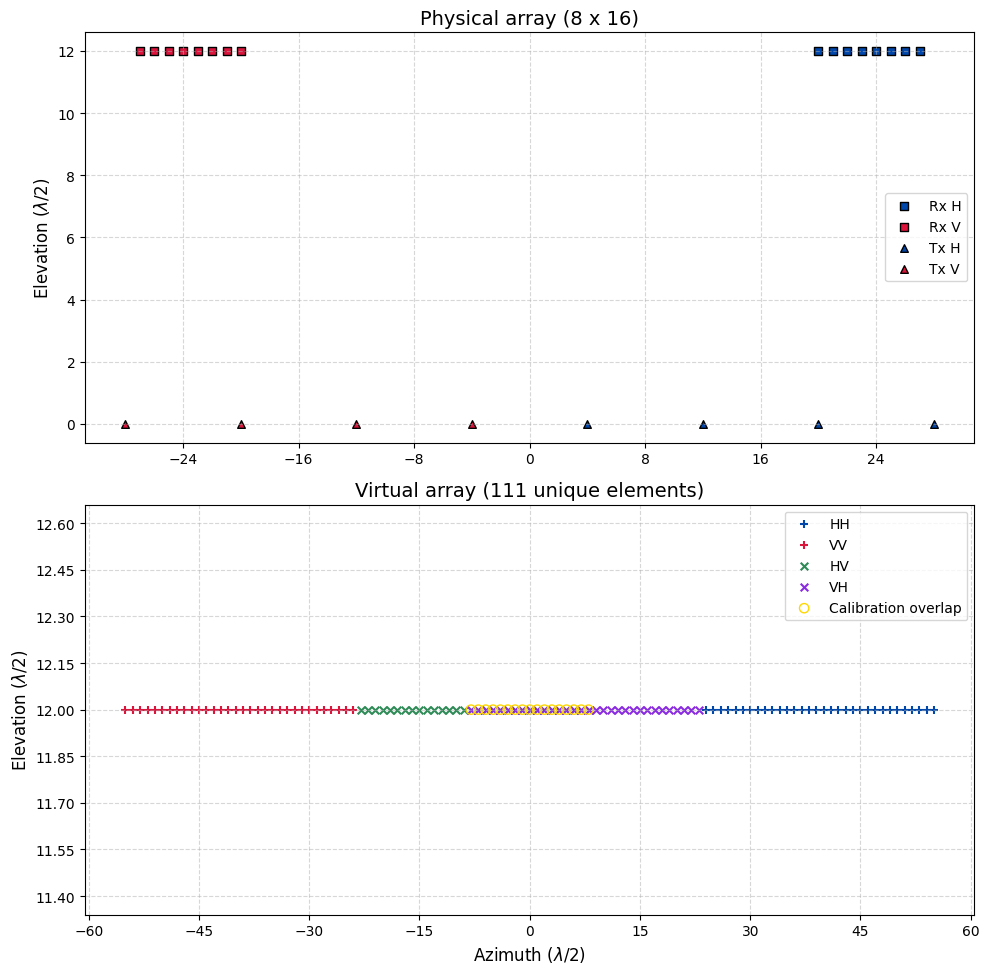

In [6]:
# rx_subarray_length = 4
# rx_subarray_spacing = 13
# rx_elevation = 18
# rx_subarray_ula = np.arange(0, rx_subarray_length, 1)
# rx_h1 = np.column_stack((rx_subarray_spacing / 2 + rx_subarray_ula, rx_elevation * np.ones_like(rx_subarray_ula)))
# rx_v2 = np.column_stack(
#     (rx_h1[-1][0] + rx_subarray_spacing + rx_subarray_ula, rx_elevation * np.ones_like(rx_subarray_ula))
# )
# rx_v1 = np.column_stack((-rx_subarray_spacing / 2 - rx_subarray_ula, rx_elevation * np.ones_like(rx_subarray_ula)))
# rx_h2 = np.column_stack(
#     (rx_v1[-1][0] - rx_subarray_spacing - rx_subarray_ula, rx_elevation * np.ones_like(rx_subarray_ula))
# )
# rx_h = np.vstack((rx_h1, rx_h2))
# rx_v = np.vstack((rx_v1, rx_v2))

rx_subarray_length = 8
rx_subarray_spacing = 40
rx_elevation = 12
rx_subarray_ula = np.arange(0, rx_subarray_length, 1)
rx_h = np.column_stack((rx_subarray_spacing / 2 + rx_subarray_ula, rx_elevation * np.ones_like(rx_subarray_ula)))
rx_v = np.column_stack((-rx_subarray_spacing / 2 - rx_subarray_ula, rx_elevation * np.ones_like(rx_subarray_ula)))

tx_count = 4
tx_spacing = rx_subarray_length
tx_ula = np.arange(0, tx_count * tx_spacing, tx_spacing)
tx_h = np.column_stack((tx_spacing / 2 + tx_ula, np.zeros_like(tx_ula)))
tx_v = -tx_h

mimo = ArraySynthesizer(name="", highlight_overlaps=True)
mimo.set_arrays(tx_h=tx_h, rx_h=rx_h, tx_v=tx_v, rx_v=rx_v)
mimo.plot_topology(marker_size=30)